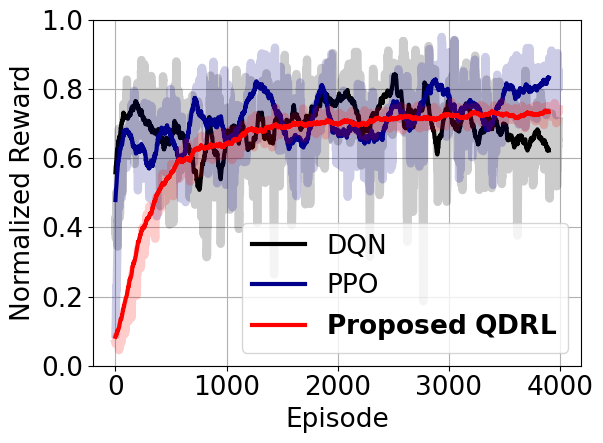

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

MAQDRL_scores = np.load('Rewards_DRL/MAQDRL_UAV_scores.npy')/1900
# MADQN_scores_small = np.load('Rewards_MADRL/DQN_UAV_scores_small.npy')/1800
MADQN_scores_large = np.load('Rewards_DRL/DQN_UAV_scores.npy')/1900
# MAPPO_scores_small = np.load('Rewards_MADRL/PPO_UAV_scores_small.npy')/1800
MAPPO_scores_large = np.load('Rewards_DRL/PPO_UAV_scores.npy')/1900
plt.rcParams.update({'font.size': 19})
# plt.plot(moving_average(MADQN_scores_small, window_size=200), label='MA-DQN (small): 155x3', color='blue', linewidth=2)
plt.plot(moving_average(MADQN_scores_large, window_size=10),color='black', linewidth=6, alpha=0.2)
plt.plot(moving_average(MADQN_scores_large, window_size=100), label='DQN', color='black', linewidth=3)
# plt.plot(moving_average(MAPPO_scores_small, window_size=200), label='MA-PPO (small): actor=155x3, critic=31x3', color='green', linewidth=2)
plt.plot(moving_average(MAPPO_scores_large, window_size=10), color='darkblue', linewidth=6, alpha=0.2)
plt.plot(moving_average(MAPPO_scores_large, window_size=100), label='PPO', color='darkblue', linewidth=3)
plt.plot(moving_average(MAQDRL_scores, window_size=10), color='red', linewidth=6, alpha=0.2)
plt.plot(moving_average(MAQDRL_scores, window_size=100), label=r'$\mathbf{Proposed~QDRL}$', color='red', linewidth=3)
plt.xlabel('Episode')
plt.ylabel('Normalized Reward')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('QDRL_vs_baselines.pdf')
plt.show()

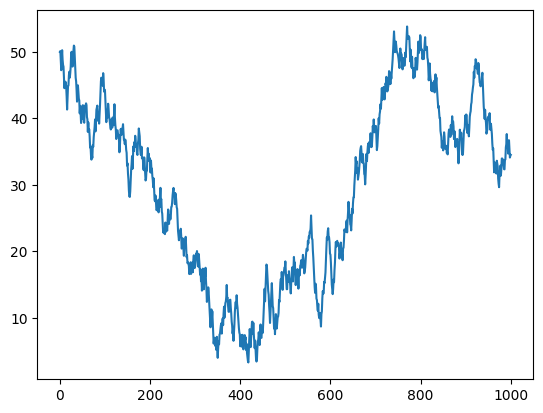

In [45]:
import numpy as np
import matplotlib.pyplot as plt

y = [50]

for _ in range(1000):
    step = np.random.uniform(-2, 2)   # small change
    y.append(y[-1] + step)
plt.plot(y)

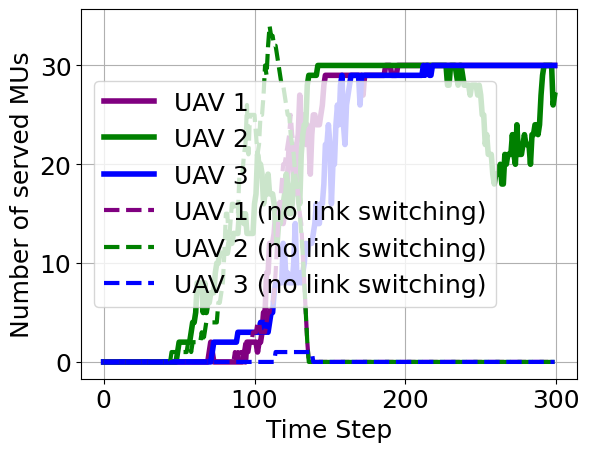

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

step = np.linspace(0, 300, 296)
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

number_of_sp_users_UAV0 = np.load('Simulation_results/number_of_sp_users_UAV0.npy')
number_of_sp_users_UAV1 = np.load('Simulation_results/number_of_sp_users_UAV1.npy')
number_of_sp_users_UAV2 = np.load('Simulation_results/number_of_sp_users_UAV2.npy')

number_of_sp_users_UAV0_no_switching = np.load('Simulation_results/number_of_sp_users_UAV0_no_switching.npy')
number_of_sp_users_UAV1_no_switching = np.load('Simulation_results/number_of_sp_users_UAV1_no_switching.npy')
number_of_sp_users_UAV2_no_switching = np.load('Simulation_results/number_of_sp_users_UAV2_no_switching.npy')

# print(number_of_sp_users_UAV0_no_switching, number_of_sp_users_UAV1_no_switching, number_of_sp_users_UAV2_no_switching)

Visibility = np.load('Simulation_results/Visibility.npy')

plt.figure()
plt.rcParams.update({'font.size': 18})
plt.plot(number_of_sp_users_UAV0, label='UAV 1', color='purple', linewidth=4)
plt.plot(number_of_sp_users_UAV1, label='UAV 2', color='green', linewidth=4)
plt.plot(number_of_sp_users_UAV2, label='UAV 3', color='blue', linewidth=4)
plt.plot(number_of_sp_users_UAV0_no_switching, label='UAV 1 (no link switching)', color='purple', linewidth=3, linestyle='dashed')
plt.plot(number_of_sp_users_UAV1_no_switching, label='UAV 2 (no link switching)', color='green', linewidth=3, linestyle='dashed')
plt.plot(number_of_sp_users_UAV2_no_switching, label='UAV 3 (no link switching)', color='blue', linewidth=3, linestyle='dashed')
plt.xlabel('Time Step')
plt.ylabel('Number of served MUs')
plt.grid(True)
plt.legend()


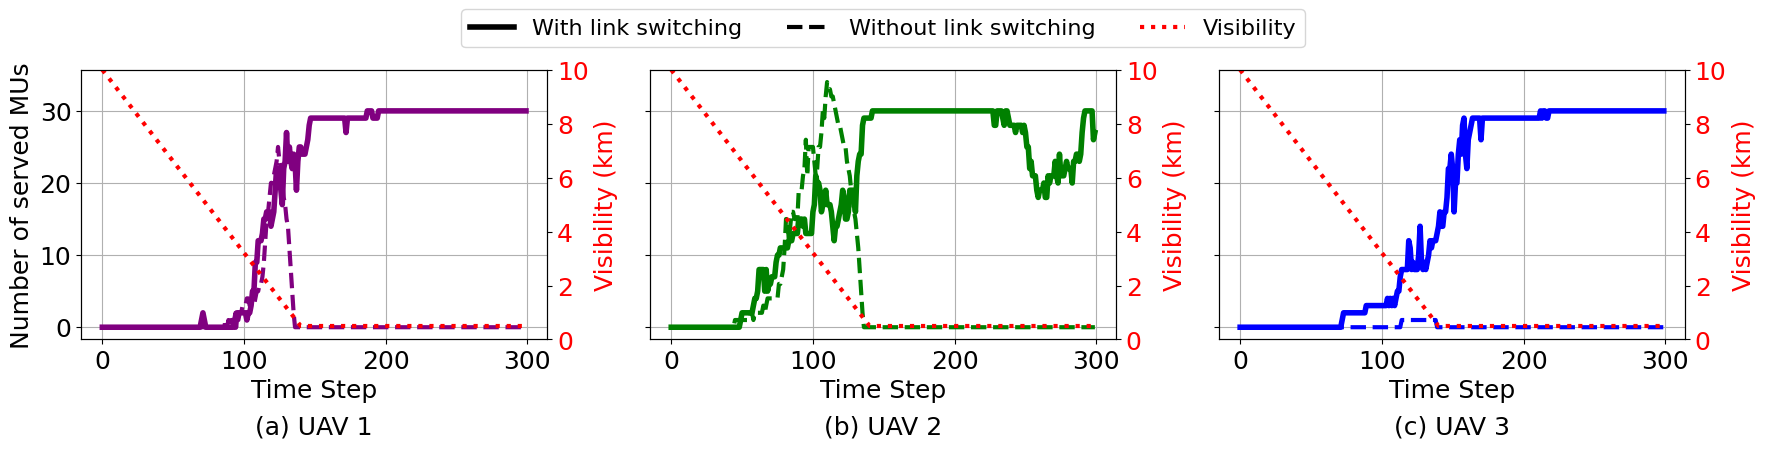

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load data
number_of_sp_users_UAV0 = np.load('Simulation_results/number_of_sp_users_UAV0.npy')
number_of_sp_users_UAV1 = np.load('Simulation_results/number_of_sp_users_UAV1.npy')
number_of_sp_users_UAV2 = np.load('Simulation_results/number_of_sp_users_UAV2.npy')

number_of_sp_users_UAV0_no_switching = np.load('Simulation_results/number_of_sp_users_UAV0_no_switching.npy')
number_of_sp_users_UAV1_no_switching = np.load('Simulation_results/number_of_sp_users_UAV1_no_switching.npy')
number_of_sp_users_UAV2_no_switching = np.load('Simulation_results/number_of_sp_users_UAV2_no_switching.npy')

visibility = np.load('Simulation_results/Visibility.npy')

plt.rcParams.update({'font.size': 18})

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# ---------------- UAV 1 ----------------
axs[0].plot(
    number_of_sp_users_UAV0,
    color='purple',
    linewidth=4
)

axs[0].plot(
    number_of_sp_users_UAV0_no_switching,
    color='purple',
    linewidth=3,
    linestyle='--'
)

axs[0].set_xlabel('Time Step')
axs[0].set_ylabel('Number of served MUs')
axs[0].grid(True)

ax2_0 = axs[0].twinx()
ax2_0.plot(
    visibility,
    color='red',
    linewidth=3,
    linestyle=':'
)

ax2_0.set_ylabel('Visibility (km)', color='red')
ax2_0.tick_params(axis='y', labelcolor='red')
ax2_0.set_ylim(0, 10)

# ---------------- UAV 2 ----------------
axs[1].plot(
    number_of_sp_users_UAV1,
    color='green',
    linewidth=4
)

axs[1].plot(
    number_of_sp_users_UAV1_no_switching,
    color='green',
    linewidth=3,
    linestyle='--'
)

axs[1].set_xlabel('Time Step')
axs[1].grid(True)

ax2_1 = axs[1].twinx()
ax2_1.plot(
    visibility,
    color='red',
    linewidth=3,
    linestyle=':'
)

ax2_1.set_ylabel('Visibility (km)', color='red')
ax2_1.tick_params(axis='y', labelcolor='red')
ax2_1.set_ylim(0, 10)

# ---------------- UAV 3 ----------------
axs[2].plot(
    number_of_sp_users_UAV2,
    color='blue',
    linewidth=4
)

axs[2].plot(
    number_of_sp_users_UAV2_no_switching,
    color='blue',
    linewidth=3,
    linestyle='--'
)

axs[2].set_xlabel('Time Step')
axs[2].grid(True)

ax2_2 = axs[2].twinx()
ax2_2.plot(
    visibility,
    color='red',
    linewidth=3,
    linestyle=':'
)

ax2_2.set_ylabel('Visibility (km)', color='red')
ax2_2.tick_params(axis='y', labelcolor='red')
ax2_2.set_ylim(0, 10)

# ---------------- Subfigure labels ----------------
axs[0].text(
    0.5, -0.28, '(a) UAV 1',
    transform=axs[0].transAxes,
    ha='center',
    va='top',
    fontsize=18
)

axs[1].text(
    0.5, -0.28, '(b) UAV 2',
    transform=axs[1].transAxes,
    ha='center',
    va='top',
    fontsize=18
)

axs[2].text(
    0.5, -0.28, '(c) UAV 3',
    transform=axs[2].transAxes,
    ha='center',
    va='top',
    fontsize=18
)

# ---------------- Global legend ----------------
legend_handles = [
    Line2D(
        [0], [0],
        color='black',
        linewidth=4,
        label='With link switching'
    ),
    Line2D(
        [0], [0],
        color='black',
        linewidth=3,
        linestyle='--',
        label='Without link switching'
    ),
    Line2D(
        [0], [0],
        color='red',
        linewidth=3,
        linestyle=':',
        label='Visibility'
    )
]

fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=3,
    fontsize=16,
    frameon=True
)

# Leave room for the legend
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    'Number_of_served_MUs_and_Visibility.pdf',
    bbox_inches='tight'
)

plt.show()

In [ ]:
# print(visibility)

[10.          9.9321312   9.8642624   9.7963936   9.7285248   9.660656
  9.5927872   9.5249184   9.45704959  9.38918079  9.32131199  9.25344319
  9.18557439  9.11770559  9.04983679  8.98196799  8.91409919  8.84623039
  8.77836159  8.71049279  8.64262399  8.57475519  8.50688639  8.43901759
  8.37114878  8.30327998  8.23541118  8.16754238  8.09967358  8.03180478
  7.96393598  7.89606718  7.82819838  7.76032958  7.69246078  7.62459198
  7.55672318  7.48885438  7.42098558  7.35311677  7.28524797  7.21737917
  7.14951037  7.08164157  7.01377277  6.94590397  6.87803517  6.81016637
  6.74229757  6.67442877  6.60655997  6.53869117  6.47082237  6.40295357
  6.33508477  6.26721596  6.19934716  6.13147836  6.06360956  5.99574076
  5.92787196  5.86000316  5.79213436  5.72426556  5.65639676  5.58852796
  5.52065916  5.45279036  5.38492156  5.31705276  5.24918395  5.18131515
  5.11344635  5.04557755  4.97770875  4.90983995  4.84197115  4.77410235
  4.70623355  4.63836475  4.57049595  4.50262715  4.4